# Stellar Classes — Data Exploration
Kaggle Playground Series S6E6  
Multiclass classification: GALAXY / QSO / STAR

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

DATA_DIR   = 'data/'
CAT_COLS   = ['spectral_type', 'galaxy_population']
TARGET_COL = 'class'
ID_COL     = 'id'

NUM_COLS   = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
CLASSES    = ['GALAXY', 'QSO', 'STAR']

## 1. Load & basic shape

In [2]:
train = pd.read_csv(f'{DATA_DIR}train.csv')
test  = pd.read_csv(f'{DATA_DIR}test.csv')

print(f'train : {train.shape}')
print(f'test  : {test.shape}')
train.head(3)

train : (577347, 12)
test  : (247435, 11)


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO


In [3]:
train.dtypes

id                     int64
alpha                float64
delta                float64
u                    float64
g                    float64
r                    float64
i                    float64
z                    float64
redshift             float64
spectral_type            str
galaxy_population        str
class                    str
dtype: object

## 2. Missing values

In [4]:
missing_train = train.isnull().sum()
missing_test  = test.isnull().sum()

miss = pd.DataFrame({
    'train_missing': missing_train,
    'train_%':       (missing_train / len(train) * 100).round(3),
    'test_missing':  missing_test,
    'test_%':        (missing_test  / len(test)  * 100).round(3),
})
miss[miss['train_missing'] + miss['test_missing'] > 0]

,train_missing,train_%,test_missing,test_%


## 3. Target distribution

class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64

Class proportions:
class
GALAXY    0.6538
QSO       0.2029
STAR      0.1433
Name: count, dtype: float64


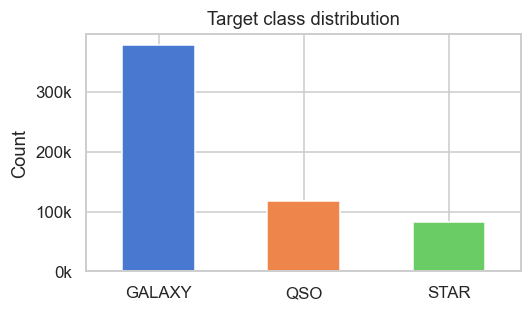

In [5]:
class_counts = train[TARGET_COL].value_counts()
print(class_counts)
print('\nClass proportions:')
print((class_counts / len(train)).round(4))

fig, ax = plt.subplots(figsize=(5, 3))
class_counts.plot(kind='bar', ax=ax, color=sns.color_palette('muted', len(class_counts)))
ax.set_title('Target class distribution')
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Numerical features — summary statistics

In [6]:
train[NUM_COLS].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
alpha,577347.0,181.617,96.243,0.012,132.161,188.681,231.830,360.000
delta,577347.0,21.835,18.934,-17.967,2.474,21.484,36.988,79.158
u,577347.0,22.442,2.018,-0.139,20.977,22.570,23.869,28.253
g,577347.0,21.007,1.795,13.535,19.865,21.468,22.293,27.620
r,577347.0,19.963,1.649,12.579,18.821,20.431,21.164,25.254
i,577347.0,19.379,1.580,11.963,18.307,19.632,20.608,27.911
z,577347.0,19.041,1.584,11.683,17.973,19.189,20.162,26.827
redshift,577347.0,0.723,0.810,-0.010,0.181,0.498,0.881,7.011


## 5. Distributions by class

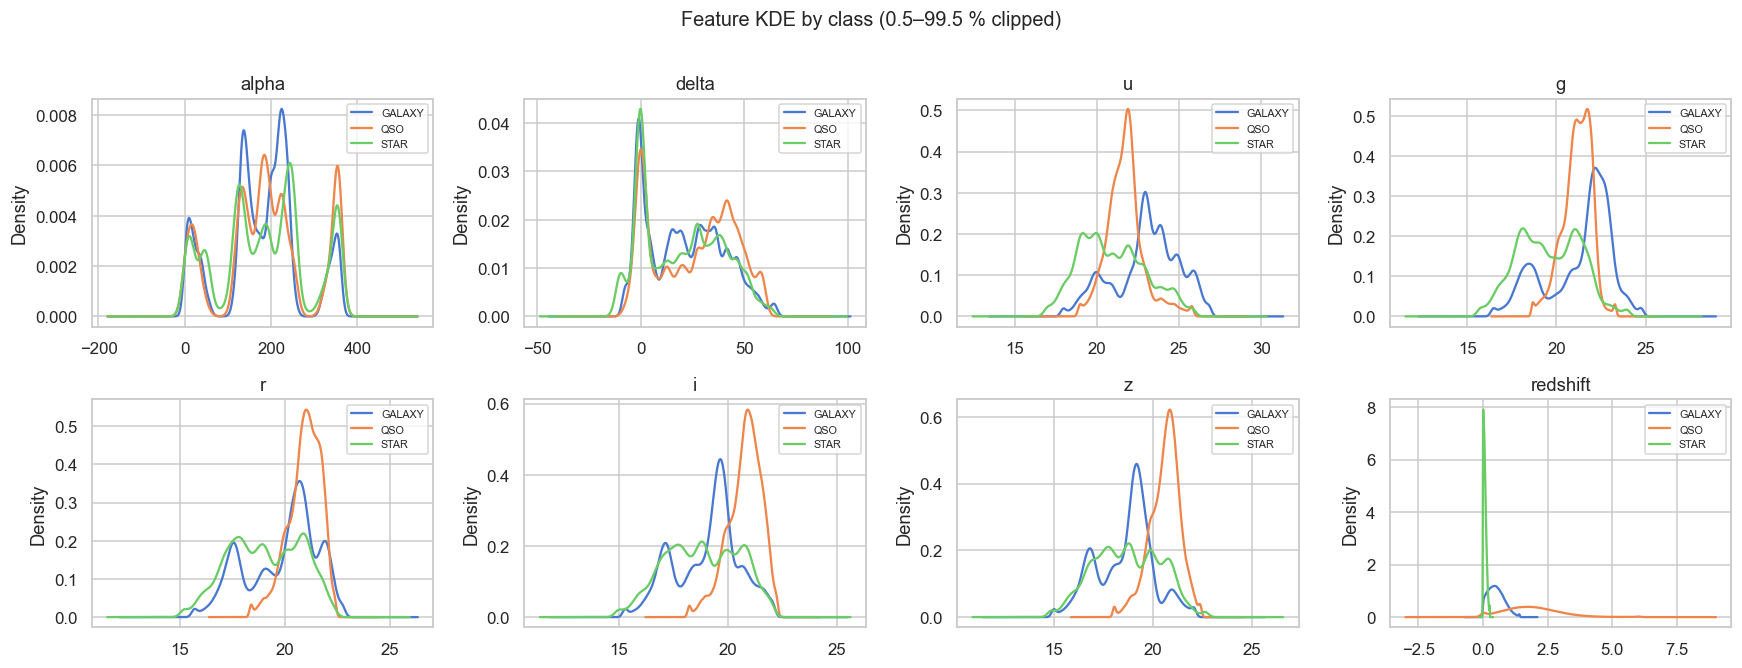

In [7]:
n_cols = 4
n_rows = int(np.ceil(len(NUM_COLS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))

palette = dict(zip(CLASSES, sns.color_palette('muted', len(CLASSES))))

for ax, col in zip(axes.flat, NUM_COLS):
    for cls in CLASSES:
        subset = train.loc[train[TARGET_COL] == cls, col].dropna()
        # clip outliers for readability
        lo, hi = subset.quantile(0.005), subset.quantile(0.995)
        subset = subset.clip(lo, hi)
        subset.plot.kde(ax=ax, label=cls, color=palette[cls], lw=1.5)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.legend(fontsize=7)

for ax in axes.flat[len(NUM_COLS):]:
    ax.set_visible(False)

fig.suptitle('Feature KDE by class (0.5–99.5 % clipped)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 6. Photometric bands — box plots

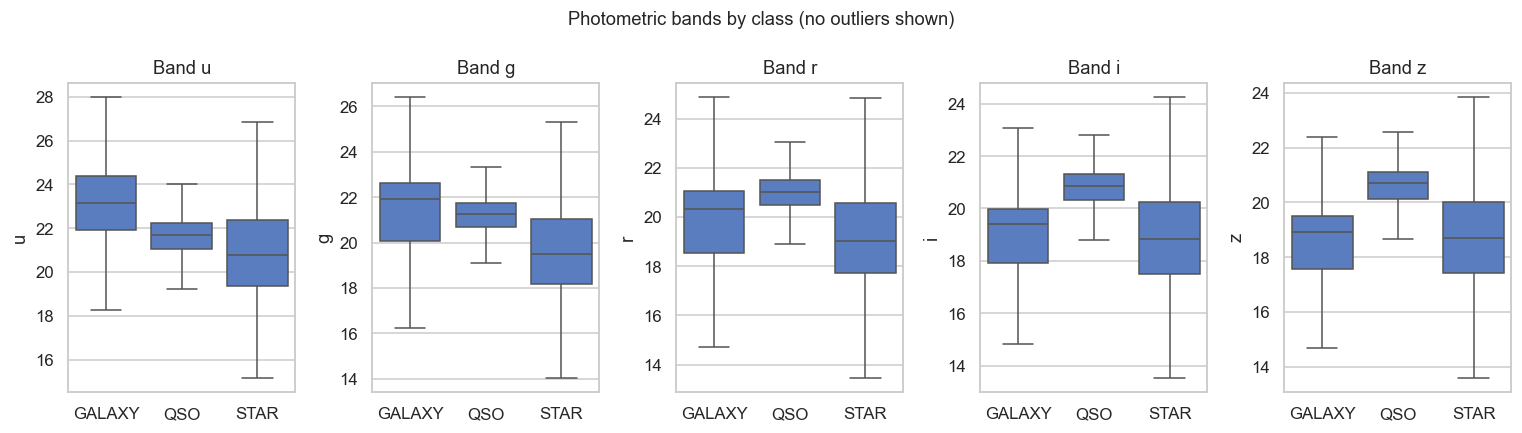

In [8]:
bands = ['u', 'g', 'r', 'i', 'z']
fig, axes = plt.subplots(1, len(bands), figsize=(14, 4), sharey=False)

for ax, band in zip(axes, bands):
    sns.boxplot(
        data=train, x=TARGET_COL, y=band, showfliers=False, ax=ax
    )
    ax.set_title(f'Band {band}')
    ax.set_xlabel('')

fig.suptitle('Photometric bands by class (no outliers shown)', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Redshift distribution

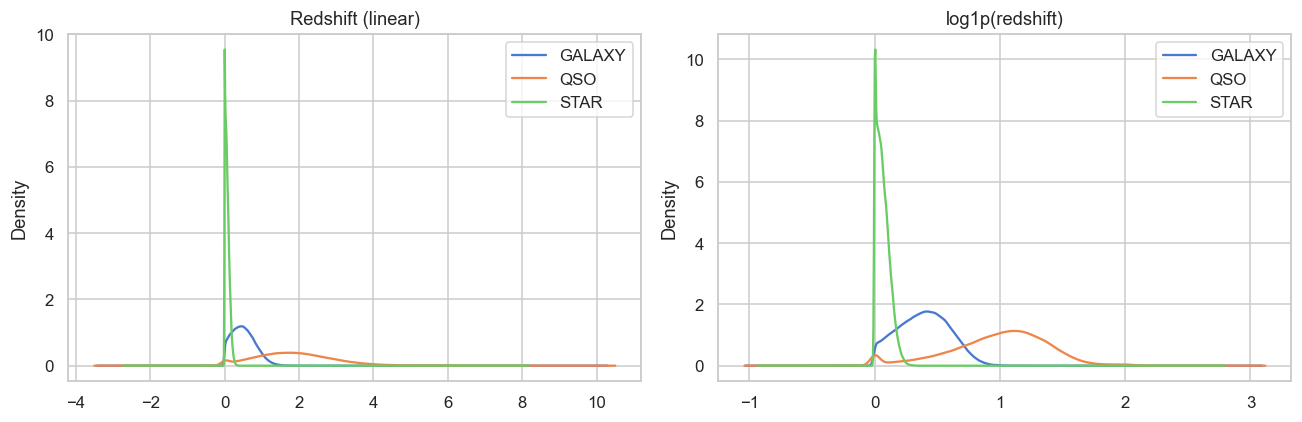

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# linear scale
for cls in CLASSES:
    vals = train.loc[train[TARGET_COL] == cls, 'redshift'].clip(0, 7)
    vals.plot.kde(ax=axes[0], label=cls, lw=1.5)
axes[0].set_title('Redshift (linear)')
axes[0].legend()

# log1p scale
for cls in CLASSES:
    vals = np.log1p(train.loc[train[TARGET_COL] == cls, 'redshift'].clip(0, 7))
    vals.plot.kde(ax=axes[1], label=cls, lw=1.5)
axes[1].set_title('log1p(redshift)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Categorical features

In [10]:
for col in CAT_COLS:
    print(f'=== {col} ===')
    ct = pd.crosstab(train[col], train[TARGET_COL], normalize='index').round(3)
    print(ct)
    print()

=== spectral_type ===
class          GALAXY    QSO   STAR
spectral_type                      
A/F             0.198  0.504  0.298
G/K             0.568  0.193  0.240
M               0.950  0.013  0.038
O/B             0.083  0.711  0.206

=== galaxy_population ===
class              GALAXY    QSO   STAR
galaxy_population                      
Blue_Cloud          0.345  0.420  0.235
Red_Sequence        0.903  0.028  0.069



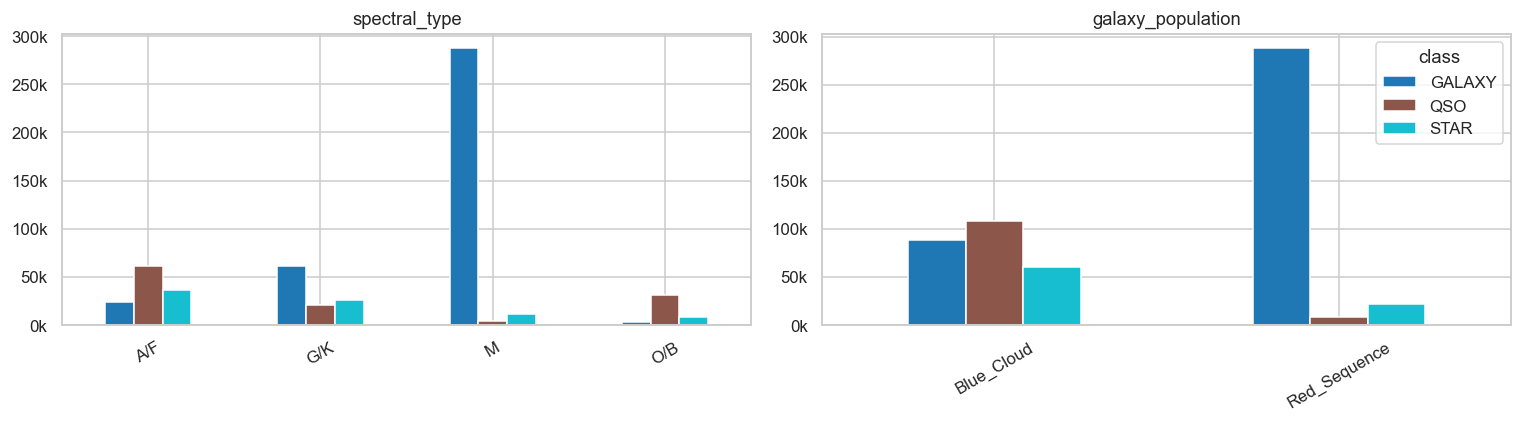

In [11]:
fig, axes = plt.subplots(1, len(CAT_COLS), figsize=(14, 4))

for ax, col in zip(axes, CAT_COLS):
    ct = pd.crosstab(train[col], train[TARGET_COL])
    ct.plot(kind='bar', ax=ax, colormap='tab10', legend=(col == CAT_COLS[-1]))
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

plt.tight_layout()
plt.show()

## 9. Sky coordinates — scatter

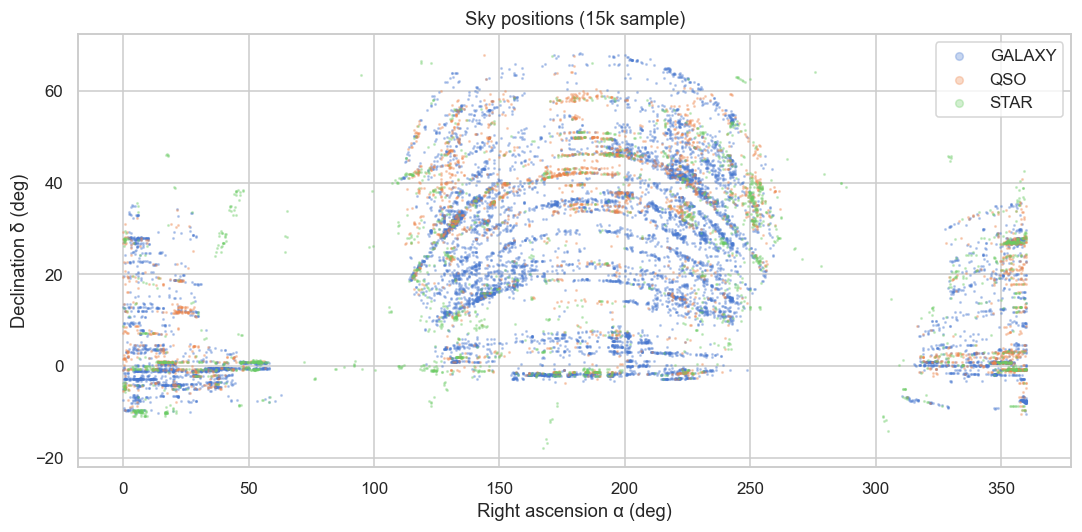

In [12]:
sample = train.sample(15_000, random_state=42)
palette = dict(zip(CLASSES, sns.color_palette('muted', len(CLASSES))))

fig, ax = plt.subplots(figsize=(10, 5))
for cls in CLASSES:
    sub = sample[sample[TARGET_COL] == cls]
    ax.scatter(sub['alpha'], sub['delta'], s=1, alpha=0.3,
               color=palette[cls], label=cls)

ax.set_xlabel('Right ascension α (deg)')
ax.set_ylabel('Declination δ (deg)')
ax.set_title('Sky positions (15k sample)')
ax.legend(markerscale=5)
plt.tight_layout()
plt.show()

## 10. Correlation matrix (numerical features)

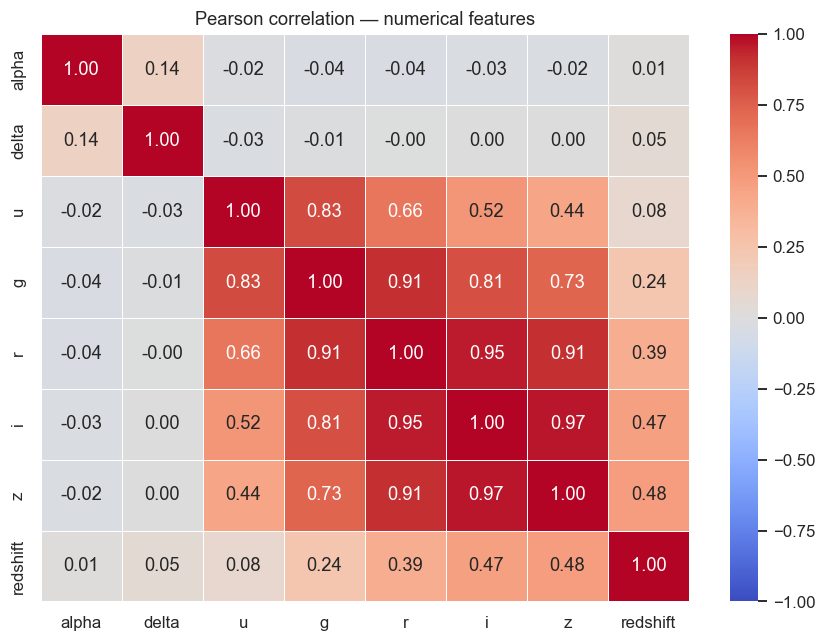

In [13]:
corr = train[NUM_COLS].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax
)
ax.set_title('Pearson correlation — numerical features')
plt.tight_layout()
plt.show()

## 11. Train / test distribution check

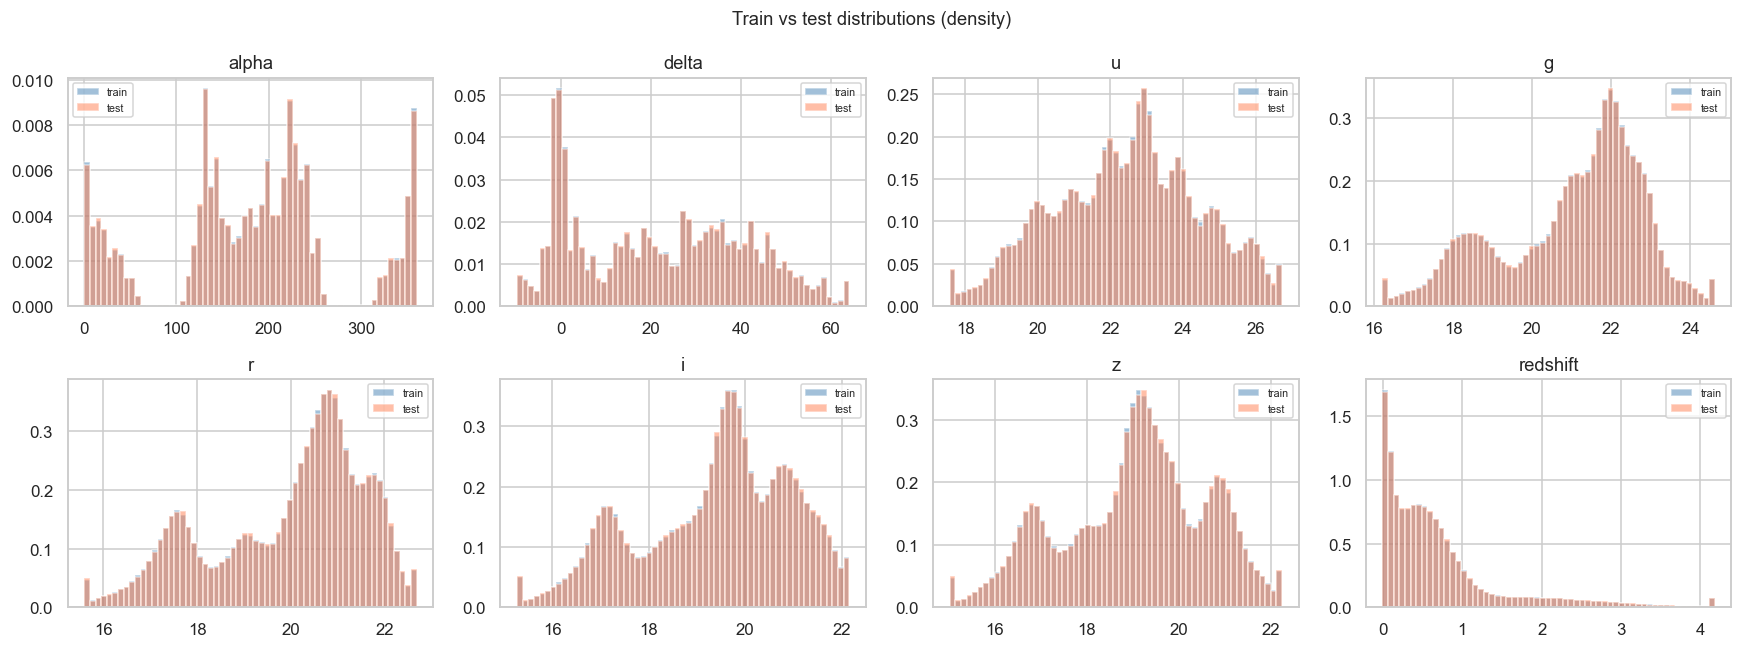

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))

for ax, col in zip(axes.flat, NUM_COLS):
    lo = min(train[col].quantile(0.005), test[col].quantile(0.005))
    hi = max(train[col].quantile(0.995), test[col].quantile(0.995))
    bins = np.linspace(lo, hi, 60)
    ax.hist(train[col].clip(lo, hi), bins=bins, density=True,
            alpha=0.5, label='train', color='steelblue')
    ax.hist(test[col].clip(lo, hi),  bins=bins, density=True,
            alpha=0.5, label='test',  color='coral')
    ax.set_title(col)
    ax.legend(fontsize=7)

fig.suptitle('Train vs test distributions (density)', fontsize=12)
plt.tight_layout()
plt.show()

## 12. Engineered feature preview — photometric colors

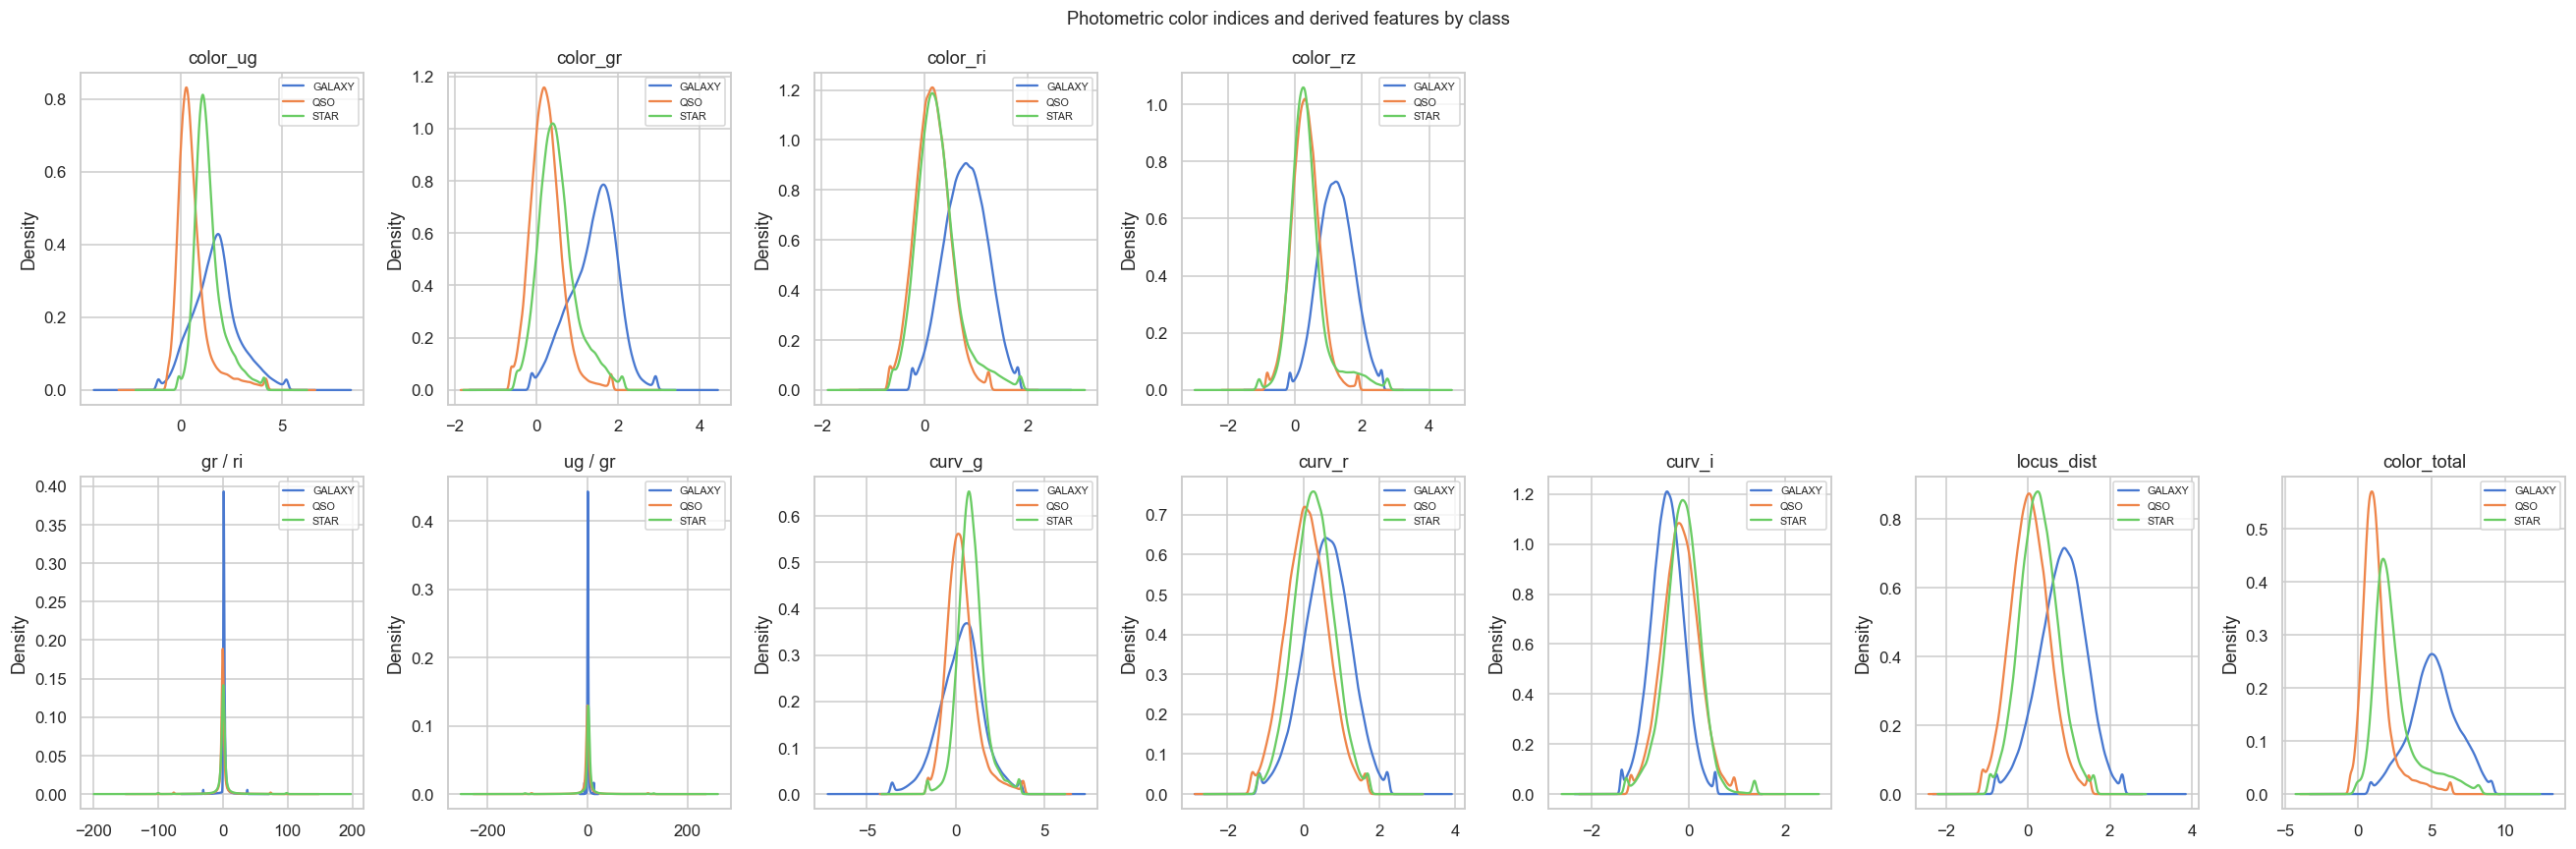

In [19]:
df = train.copy()
df['color_ug'] = df['u'] - df['g']
df['color_gr'] = df['g'] - df['r']
df['color_ri'] = df['r'] - df['i']
df['color_rz'] = df['r'] - df['z']

colors = ['color_ug', 'color_gr', 'color_ri', 'color_rz']

# derived features
derived = {
    'gr / ri':   df['color_gr'] / (df['color_ri'] + 1e-6),
    'ug / gr':   df['color_ug'] / (df['color_gr'] + 1e-6),
    'curv_g':    df['color_ug'] - df['color_gr'],
    'curv_r':    df['color_gr'] - df['color_ri'],
    'curv_i':    df['color_ri'] - df['color_rz'],
    'locus_dist': df['color_gr'] - (0.6 * df['color_ri'] + 0.1),
    'color_total': df['color_ug'] + df['color_gr'] + df['color_ri'] + df['color_rz'],
}
for name, vals in derived.items():
    df[name] = vals

fig, axes = plt.subplots(2, max(len(colors), len(derived)), figsize=(24, 8))

# row 1 — individual colors
for ax, col in zip(axes[0], colors):
    for cls in CLASSES:
        vals = df.loc[df[TARGET_COL] == cls, col]
        lo, hi = vals.quantile(0.005), vals.quantile(0.995)
        vals.clip(lo, hi).plot.kde(ax=ax, label=cls, lw=1.5)
    ax.set_title(col)
    ax.legend(fontsize=7)

# row 2 — derived features
for ax, (name, _) in zip(axes[1], derived.items()):
    for cls in CLASSES:
        vals = df.loc[df[TARGET_COL] == cls, name]
        lo, hi = vals.quantile(0.005), vals.quantile(0.995)
        vals.clip(lo, hi).plot.kde(ax=ax, label=cls, lw=1.5)
    ax.set_title(name)
    ax.legend(fontsize=7)

# hide unused axes
for ax in axes[0, len(colors):]:
    ax.set_visible(False)
for ax in axes[1, len(derived):]:
    ax.set_visible(False)

fig.suptitle('Photometric color indices and derived features by class', fontsize=12)
plt.tight_layout()
plt.show()

## 13. Photometric color space — PCA & UMAP encodings

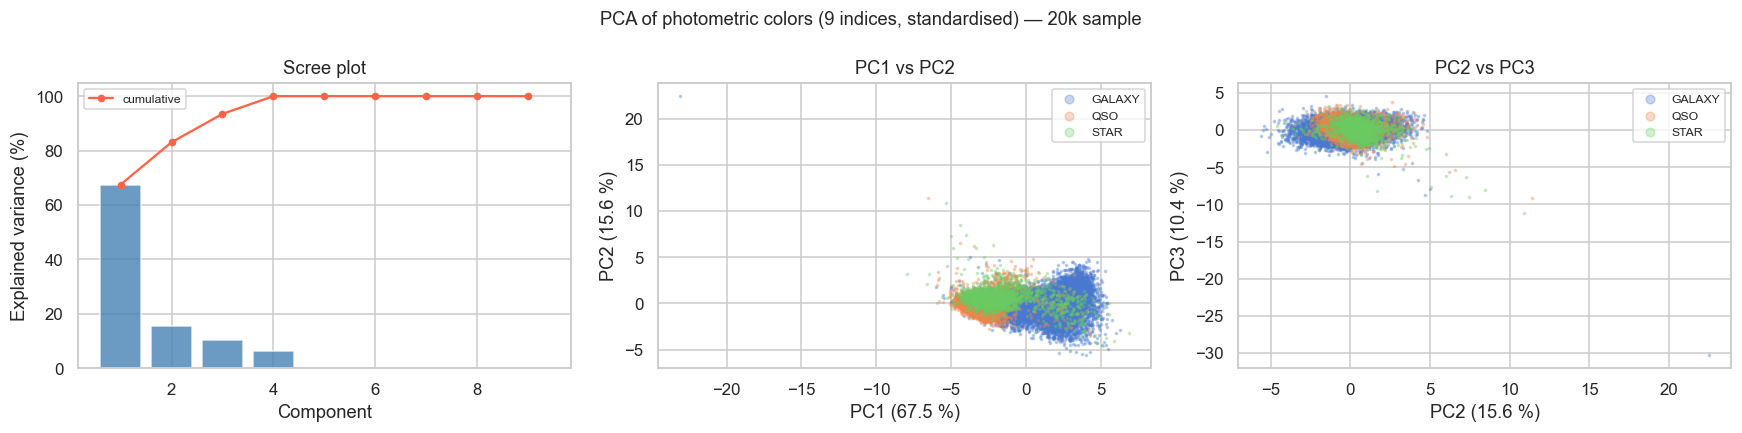

Variance captured — PC1-2: 83.1 %  |  PC1-3: 93.5 %


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

COLOR_COLS = ['color_ug', 'color_gr', 'color_ri', 'color_rz',
              'color_ui', 'color_uz', 'color_gi', 'color_gz', 'color_iz']

df = train.copy()
df['color_ug'] = df['u'] - df['g']
df['color_gr'] = df['g'] - df['r']
df['color_ri'] = df['r'] - df['i']
df['color_rz'] = df['r'] - df['z']
df['color_ui'] = df['u'] - df['i']
df['color_uz'] = df['u'] - df['z']
df['color_gi'] = df['g'] - df['i']
df['color_gz'] = df['g'] - df['z']
df['color_iz'] = df['i'] - df['z']

X_colors = StandardScaler().fit_transform(df[COLOR_COLS].values.astype(float))

# ── PCA (full 9D → keep all for scree, plot first 3) ────────────────────────
pca      = PCA(n_components=len(COLOR_COLS), random_state=31415)
pca_full = pca.fit_transform(X_colors)
evr      = pca.explained_variance_ratio_

palette  = dict(zip(CLASSES, sns.color_palette('muted', len(CLASSES))))
samp_idx = df.sample(20_000, random_state=42).index
X_samp   = pca_full[samp_idx]
y_samp   = df.loc[samp_idx, TARGET_COL]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# scree
ax = axes[0]
ax.bar(range(1, len(evr) + 1), evr * 100, color='steelblue', alpha=0.8)
ax.plot(range(1, len(evr) + 1), np.cumsum(evr) * 100,
        color='tomato', marker='o', lw=1.5, ms=4, label='cumulative')
ax.set_xlabel('Component')
ax.set_ylabel('Explained variance (%)')
ax.set_title('Scree plot')
ax.legend(fontsize=8)

# PC1 vs PC2
ax = axes[1]
for cls in CLASSES:
    m = y_samp == cls
    ax.scatter(X_samp[m, 0], X_samp[m, 1], s=2, alpha=0.3, color=palette[cls], label=cls)
ax.set_xlabel(f'PC1 ({evr[0]*100:.1f} %)')
ax.set_ylabel(f'PC2 ({evr[1]*100:.1f} %)')
ax.set_title('PC1 vs PC2')
ax.legend(markerscale=4, fontsize=8)

# PC2 vs PC3
ax = axes[2]
for cls in CLASSES:
    m = y_samp == cls
    ax.scatter(X_samp[m, 1], X_samp[m, 2], s=2, alpha=0.3, color=palette[cls], label=cls)
ax.set_xlabel(f'PC2 ({evr[1]*100:.1f} %)')
ax.set_ylabel(f'PC3 ({evr[2]*100:.1f} %)')
ax.set_title('PC2 vs PC3')
ax.legend(markerscale=4, fontsize=8)

fig.suptitle('PCA of photometric colors (9 indices, standardised) — 20k sample', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Variance captured — PC1-2: {evr[:2].sum()*100:.1f} %  |  PC1-3: {evr[:3].sum()*100:.1f} %")